In [1]:
import numpy as np

In [2]:
class LinearRegression:

    #Setting random w and b
    def __init__(self):
        self.w = np.random.randn(1)
        self.b = np.random.randn(1)

    #this is forward pass
    def forward(self, x):
        return self.w*x+self.b

    def gradients(self, x, y, y_pred):
        n = len(x)
        error = y - y_pred
        dW = (-2 / n) * np.sum(x * error)
        db = (-2 / n) * np.sum(error)

        return dW, db

In [3]:
def generate_data(n_samples=500, noise_std=0.5, random_seed=42):
    """
    Generate synthetic data using:
    y = wx + b + noise
    """

    np.random.seed(random_seed)
    x = np.random.randn(n_samples, 1)

    noise = np.random.normal(
        loc=0.0,
        scale=noise_std,
        size=(n_samples, 1)
    )

    y = 3 * x + 2 + noise

    return x, y

In [4]:
def mse_loss(y_true, y_pred):

    # MSE
    loss = np.mean((y_true - y_pred) ** 2)

    return loss

def mse_gradient(y_true, y_pred):

    return 2 * (y_pred - y_true) / len(y_true)

In [5]:
class SGD:

    def __init__(self, learning_rate=0.01):
        self.lr = learning_rate

    def step(self, model):
        for layer in model.layers:

            layer.W -= self.lr * layer.dW
            layer.b -= self.lr * layer.db

In [6]:
class Momentum:

    def __init__(self, learning_rate=0.01, beta=0.9):

        self.lr = learning_rate
        self.beta = beta

        self.velocity = {}

    def step(self, model):

        for layer in model.layers:

            if id(layer) not in self.velocity:

                self.velocity[id(layer)] = {
                    "dW": np.zeros_like(layer.W),
                    "db": np.zeros_like(layer.b)
                }

            v = self.velocity[id(layer)]

            v["dW"] = self.beta * v["dW"] + (1 - self.beta) * layer.dW
            v["db"] = self.beta * v["db"] + (1 - self.beta) * layer.db

            layer.W -= self.lr * v["dW"]
            layer.b -= self.lr * v["db"]

In [7]:
class Adam:

    def __init__(self,
                 learning_rate=0.001,
                 beta1=0.9,
                 beta2=0.999,
                 epsilon=1e-8):
        
        self.lr = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon

        self.state = {}

        self.t = 0

    def step(self, model):

        self.t += 1

        for layer in model.layers:

            if id(layer) not in self.state:

                self.state[id(layer)] = {

                    "mw": 0,
                    "mb": 0,
                    "vw": 0,
                    "vb": 0

                }

            s = self.state[id(layer)]

            s["mw"] = self.beta1 * s["mw"] + (1 - self.beta1) * layer.dW
            s["mb"] = self.beta1 * s["mb"] + (1 - self.beta1) * layer.db

            s["vw"] = self.beta2 * s["vw"] + (1 - self.beta2) * (layer.dW ** 2)
            s["vb"] = self.beta2 * s["vb"] + (1 - self.beta2) * (layer.db ** 2)

            mw_hat = s["mw"] / (1 - self.beta1 ** self.t)
            mb_hat = s["mb"] / (1 - self.beta1 ** self.t)

            vw_hat = s["vw"] / (1 - self.beta2 ** self.t)
            vb_hat = s["vb"] / (1 - self.beta2 ** self.t)

            layer.W -= self.lr * mw_hat / (np.sqrt(vw_hat) + self.epsilon)
            layer.b -= self.lr * mb_hat / (np.sqrt(vb_hat) + self.epsilon)

In [8]:
class ReLU:

    def forward(self, X):

        self.X = X

        return np.maximum(0, X)

    def backward(self, dA):

        dZ = dA.copy()

        dZ[self.X <= 0] = 0

        return dZ

In [9]:
class LinearLayer:

    def __init__(self, input_features, output_features):

        # He initialization
        self.W = np.random.randn(input_features, output_features) * np.sqrt(2.0 / input_features)
        self.b = np.zeros((1, output_features))

        # Variables used during forward/backward pass
        self.X = None
        self.dW = None
        self.db = None

    def forward(self, X):
        """
        Forward Pass

        Z = XW + b

        X : (batch_size, input_features)
        W : (input_features, output_features)
        b : (1, output_features)

        Returns:
            Z : (batch_size, output_features)
        """

        self.X = X

        Z = X @ self.W + self.b

        return Z

    def backward(self, dZ):
        """
        Backward Pass

        dZ : Gradient received from the next layer
             Shape -> (batch_size, output_features)

        Computes:
            dW = Xᵀ @ dZ
            db = sum(dZ)
            dX = dZ @ Wᵀ

        Returns:
            dX : Gradient passed to the previous layer
        """

        batch_size = self.X.shape[0]

        # Gradient w.r.t. weights
        self.dW = (self.X.T @ dZ) / batch_size

        # Gradient w.r.t. bias
        self.db = np.sum(
            dZ,
            axis=0,
            keepdims=True
        ) / batch_size

        # Gradient for previous layer
        dX = dZ @ self.W.T

        return dX

In [20]:
class NeuralNetwork:

    def __init__(self):

        self.layer1 = LinearLayer(
            input_features=1,
            output_features=8
        )

        self.relu = ReLU()

        self.layer2 = LinearLayer(
            input_features=8,
            output_features=1
        )

        self.layers = [
            self.layer1,
            self.layer2
        ]

    def forward(self, X):

        X = self.layer1.forward(X)

        X = self.relu.forward(X)

        X = self.layer2.forward(X)

        return X

    def backward(self, dLoss):

        dA = self.layer2.backward(dLoss)

        dA = self.relu.backward(dA)

        self.layer1.backward(dA)

In [11]:
def train(model, optimizer, x, y, epochs):

    history = []

    for epoch in range(epochs):

        # ---------- Forward ----------
        prediction = model.forward(x)

        # ---------- Loss ----------
        loss = mse_loss(y, prediction)

        # ---------- Backward ----------
        dLoss = mse_gradient(y, prediction)

        model.backward(dLoss)

        # ---------- Update ----------
        optimizer.step(model)

        history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch:3d} | Loss = {loss:.6f}")

    return history

In [12]:
import matplotlib.pyplot as plt

def main():

    # Generate dataset
    x, y = generate_data()

    epochs = 500

    histories = {}

    optimizers = {
        "SGD": SGD(learning_rate=0.01),
        "Momentum": Momentum(learning_rate=0.01, beta=0.9),
        "Adam": Adam(learning_rate=0.001)
    }

    # Save identical initialization
    initial_model = NeuralNetwork()

    initial_W1 = initial_model.layer1.W.copy()
    initial_b1 = initial_model.layer1.b.copy()

    initial_W2 = initial_model.layer2.W.copy()
    initial_b2 = initial_model.layer2.b.copy()

    for name, optimizer in optimizers.items():

        model = NeuralNetwork()

        # Same initialization for every optimizer
        model.layer1.W = initial_W1.copy()
        model.layer1.b = initial_b1.copy()

        model.layer2.W = initial_W2.copy()
        model.layer2.b = initial_b2.copy()

        history = train(
            model,
            optimizer,
            x,
            y,
            epochs
        )

        histories[name] = history

        print(f"\n{name}")
        print("Layer1 Weight")
        print(model.layer1.W)

        print("Layer2 Weight")
        print(model.layer2.W)

    # Plot
    plt.figure(figsize=(10, 6))

    for name, history in histories.items():
        plt.plot(history, label=name)

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Optimizer Comparison")

    plt.legend()
    plt.grid(True)

    plt.show()


Epoch   0 | Loss = 4.105626
Epoch  10 | Loss = 4.094368
Epoch  20 | Loss = 4.083168
Epoch  30 | Loss = 4.072023
Epoch  40 | Loss = 4.060933
Epoch  50 | Loss = 4.049897
Epoch  60 | Loss = 4.038914
Epoch  70 | Loss = 4.027982
Epoch  80 | Loss = 4.017105
Epoch  90 | Loss = 4.006281
Epoch 100 | Loss = 3.995512
Epoch 110 | Loss = 3.984794
Epoch 120 | Loss = 3.974126
Epoch 130 | Loss = 3.963514
Epoch 140 | Loss = 3.952956
Epoch 150 | Loss = 3.942452
Epoch 160 | Loss = 3.932003
Epoch 170 | Loss = 3.921607
Epoch 180 | Loss = 3.911261
Epoch 190 | Loss = 3.900961
Epoch 200 | Loss = 3.890711
Epoch 210 | Loss = 3.880515
Epoch 220 | Loss = 3.870371
Epoch 230 | Loss = 3.860278
Epoch 240 | Loss = 3.850232
Epoch 250 | Loss = 3.840236
Epoch 260 | Loss = 3.830291
Epoch 270 | Loss = 3.820397
Epoch 280 | Loss = 3.810551
Epoch 290 | Loss = 3.800747
Epoch 300 | Loss = 3.790994
Epoch 310 | Loss = 3.781289
Epoch 320 | Loss = 3.771630
Epoch 330 | Loss = 3.762021
Epoch 340 | Loss = 3.752462
Epoch 350 | Loss = 3

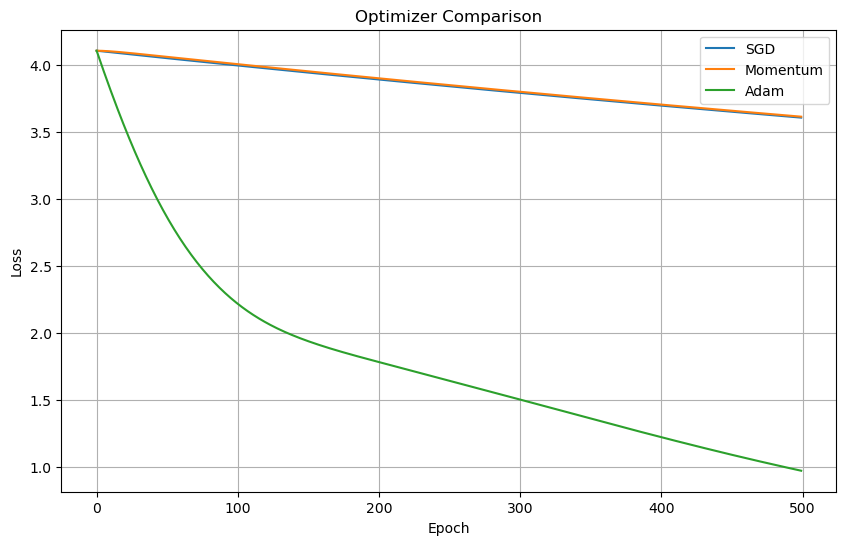

In [21]:
main()